# UF/DF Process Development

## Objective

This notebook models the ultrafiltration/diafiltration (UF/DF) stage of the
hypothetical post-conjugation ADC downstream process.

Following conjugation, the process stream may contain residual free drug-linker
and other low-molecular-weight reaction components. Diafiltration can remove
these small-molecule impurities while retaining the substantially larger ADC.

The process-development question investigated here is:

> **How many diafiltration volumes provide effective free drug-linker clearance
> while maintaining acceptable ADC recovery?**

The dataset used in this notebook is simulated and does not represent
experimental measurements from a specific ADC or UF/DF process.

In [3]:
import sys
print(sys.executable)

c:\Users\trasn\OneDrive\Dokumente\programing\adc-downstream-process-development\.venv\Scripts\python.exe


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development')

## UF/DF screening design

The number of diafiltration volumes (DV) is selected as the primary process
parameter for the initial UF/DF study.

Seven conditions are evaluated:

**0, 1, 2, 3, 4, 5, and 6 diafiltration volumes**

For each condition, two process responses will be simulated:

- residual free drug-linker (ppm);
- ADC recovery (%).

Increasing the number of diafiltration volumes is expected to improve
small-molecule impurity clearance. However, extended processing may also
result in gradual product loss.

The objective is therefore to identify a practical balance between impurity
clearance and ADC recovery rather than simply maximizing the number of
diafiltration volumes.

In [6]:
diafiltration_volumes = np.arange(0, 7)

ufdf_design = pd.DataFrame({
    "diafiltration_volumes": diafiltration_volumes
})

ufdf_design

,diafiltration_volumes
0,0
1,1
2,2
3,3
4,4
5,5
6,6


In [7]:
ufdf_design.shape

(7, 1)

## Simulation assumptions

Residual free drug-linker is modelled using an exponential clearance
relationship with increasing diafiltration volumes.

This reflects the general principle that a freely permeable small-molecule
impurity is removed rapidly during the initial diafiltration volumes, while
the absolute amount removed per additional volume decreases as the residual
impurity concentration becomes lower.

ADC recovery is modelled separately and decreases gradually with increasing
processing intensity.

The numerical relationships used here are simplified and hypothetical. They
are intended for process-development data analysis and do not represent
measurements from a specific membrane, ADC, or manufacturing process.

In [8]:
rng = np.random.default_rng(42)

ufdf_results = ufdf_design.copy()

# Starting free drug-linker concentration
initial_free_linker_ppm = 1000

# Exponential clearance of freely permeable small molecule
ufdf_results["free_drug_linker_ppm"] = (
    initial_free_linker_ppm
    * np.exp(-ufdf_results["diafiltration_volumes"])
)

# Add modest simulated process variability after the starting condition
noise = rng.normal(0, 0.05, len(ufdf_results))

ufdf_results["free_drug_linker_ppm"] = (
    ufdf_results["free_drug_linker_ppm"] * (1 + noise)
)

# Keep the defined starting concentration exactly at 1000 ppm
ufdf_results.loc[0, "free_drug_linker_ppm"] = initial_free_linker_ppm

# Gradual product loss with increasing diafiltration volumes
ufdf_results["recovery_percent"] = (
    100
    - 0.8 * ufdf_results["diafiltration_volumes"]
    + rng.normal(0, 0.25, len(ufdf_results))
)

# Keep starting recovery at 100%
ufdf_results.loc[0, "recovery_percent"] = 100

ufdf_results.round(2)

,diafiltration_volumes,free_drug_linker_ppm,recovery_percent
0,0,1000.00,100.00
1,1,348.75,99.20
2,2,140.41,98.19
3,3,52.13,97.82
4,4,16.53,96.99
5,5,6.30,96.02
6,6,2.49,95.48


## Initial assessment of simulated UF/DF performance

The simulated dataset shows rapid clearance of residual free drug-linker during
the first diafiltration volumes, followed by progressively smaller absolute
reductions at higher DV.

ADC recovery decreases more gradually as diafiltration proceeds. This creates
a process-development trade-off between additional impurity clearance and
continued product loss.

The next analysis will quantify this relationship and identify a practical
diafiltration endpoint.

In [9]:
ufdf_file = PROCESSED_DIR / "adc_ufdf_simulated_results.csv"

ufdf_results.to_csv(
    ufdf_file,
    index=False
)

ufdf_file

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development/data/processed/adc_ufdf_simulated_results.csv')

In [10]:
pd.read_csv(ufdf_file)

,diafiltration_volumes,free_drug_linker_ppm,recovery_percent
0,0,1000.000000,100.000000
1,1,348.750003,99.195800
2,2,140.413409,98.186739
3,3,52.128466,97.819849
4,4,16.528916,96.994448
5,5,6.299246,96.016508
6,6,2.494596,95.481810


## UF/DF process-performance visualization

Residual free drug-linker and ADC recovery are plotted as a function of
diafiltration volume to visualize the competing effects of impurity clearance
and product retention.

The objective is to identify the region where additional diafiltration provides
only limited additional impurity clearance while ADC recovery continues to
decrease.

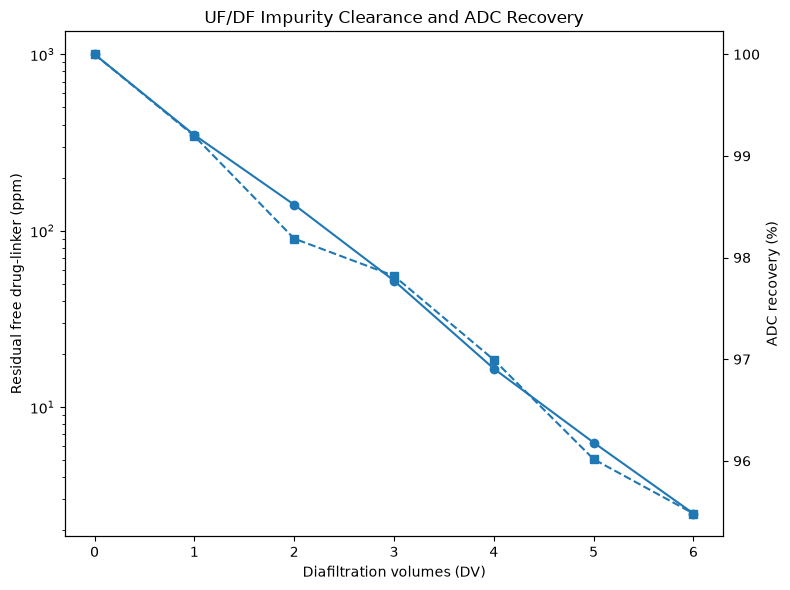

In [11]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Free drug-linker
ax1.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["free_drug_linker_ppm"],
    marker="o"
)

ax1.set_xlabel("Diafiltration volumes (DV)")
ax1.set_ylabel("Residual free drug-linker (ppm)")
ax1.set_yscale("log")

# ADC recovery on a second y-axis
ax2 = ax1.twinx()

ax2.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["recovery_percent"],
    marker="s",
    linestyle="--"
)

ax2.set_ylabel("ADC recovery (%)")

plt.title("UF/DF Impurity Clearance and ADC Recovery")

fig.tight_layout()
plt.show()

### Definition of a preliminary UF/DF endpoint

To support process selection, two hypothetical development criteria are applied:

- residual free drug-linker ≤ 20 ppm;
- ADC recovery ≥ 96%.

These thresholds are used only as decision criteria for the simulated case
study and should not be interpreted as universal ADC product specifications.

The preferred UF/DF endpoint will be the lowest number of diafiltration volumes
that satisfies both criteria. This avoids unnecessary additional processing
once the desired impurity clearance has been achieved.

In [12]:
ufdf_candidates = ufdf_results[
    (ufdf_results["free_drug_linker_ppm"] <= 20) &
    (ufdf_results["recovery_percent"] >= 96)
].copy()

ufdf_candidates.round(2)

,diafiltration_volumes,free_drug_linker_ppm,recovery_percent
4,4,16.53,96.99
5,5,6.30,96.02


### Preliminary UF/DF endpoint selection

Both 4 DV and 5 DV satisfied the hypothetical UF/DF development criteria.

The 5-DV condition was selected as the preferred preliminary endpoint because
it reduced residual free drug-linker from 16.53 ppm at 4 DV to 6.30 ppm while
still maintaining ADC recovery above the project criterion of 96%.

This represents a trade-off between additional impurity clearance and a small
loss in product recovery.

The selected 5-DV endpoint is specific to this simulated case study and should
not be interpreted as a universal UF/DF process recommendation.

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
PROJECT_ROOT = Path("..").resolve()

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development')

In [15]:
ufdf_figure_file = FIGURES_DIR / "adc_ufdf_clearance_recovery.png"

plt.savefig(
    ufdf_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

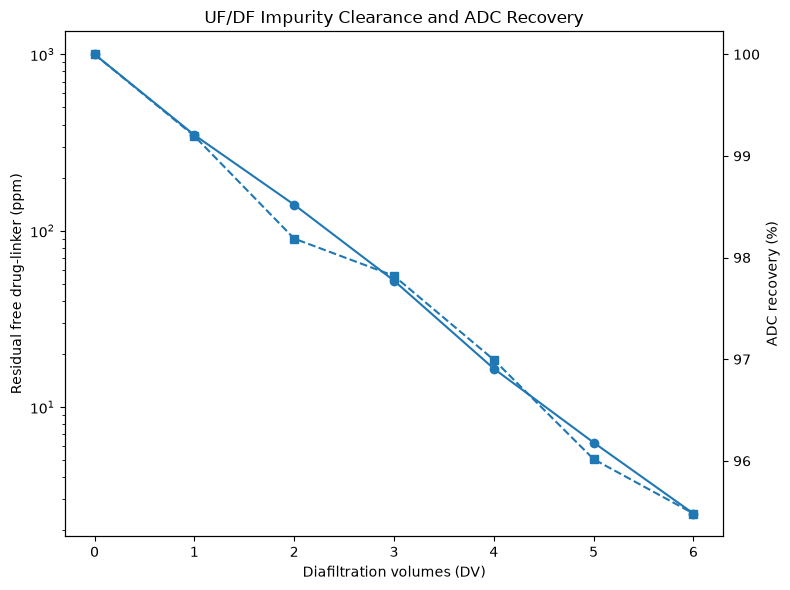

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Free drug-linker
ax1.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["free_drug_linker_ppm"],
    marker="o"
)

ax1.set_xlabel("Diafiltration volumes (DV)")
ax1.set_ylabel("Residual free drug-linker (ppm)")
ax1.set_yscale("log")

# ADC recovery on a second y-axis
ax2 = ax1.twinx()

ax2.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["recovery_percent"],
    marker="s",
    linestyle="--"
)

ax2.set_ylabel("ADC recovery (%)")

plt.title("UF/DF Impurity Clearance and ADC Recovery")

fig.tight_layout()

ufdf_figure_file = FIGURES_DIR / "adc_ufdf_clearance_recovery.png"

fig.savefig(
    ufdf_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Integration of UF/DF and multimodal chromatography

The selected UF/DF condition can be combined with the preferred multimodal
chromatography condition to estimate overall downstream process recovery.

Selected conditions:

- UF/DF endpoint: 5 diafiltration volumes
- MMC condition: pH 6.5, 300 mM NaCl, 10 mg ADC/mL resin

Overall recovery is calculated by multiplying the fractional recoveries of the
two process stages.

In [17]:
ufdf_recovery = 96.02 / 100
mmc_recovery = 92.45 / 100

overall_recovery = ufdf_recovery * mmc_recovery * 100

round(overall_recovery, 2)

88.77

## Integrated downstream process summary

The selected UF/DF and multimodal chromatography conditions were combined to
define a preliminary downstream process for the simulated ADC case study.

Although both individual unit operations maintain relatively high product
recovery, cumulative product losses result in a lower overall downstream
recovery.

In [18]:
process_summary = pd.DataFrame({
    "Process stage": [
        "Post-conjugation material",
        "UF/DF",
        "Multimodal chromatography",
        "Final downstream process"
    ],
    "Selected condition": [
        "Starting material",
        "5 DV",
        "pH 6.5, 300 mM NaCl, 10 mg/mL resin",
        "UF/DF + MMC"
    ],
    "Step recovery (%)": [
        100.00,
        96.02,
        92.45,
        np.nan
    ],
    "Cumulative recovery (%)": [
        100.00,
        96.02,
        88.77,
        88.77
    ]
})

process_summary

,Process stage,Selected condition,Step recovery (%),Cumulative recovery (%)
0,Post-conjugation material,Starting material,100.00,100.00
1,UF/DF,5 DV,96.02,96.02
2,Multimodal chromatography,"pH 6.5, 300 mM NaCl, 10 mg/mL resin",92.45,88.77
3,Final downstream process,UF/DF + MMC,NaN,88.77


## Conclusion

The simulated UF/DF development study demonstrated the trade-off between
small-molecule impurity clearance and ADC recovery during diafiltration.

Increasing diafiltration volume produced rapid clearance of residual free
drug-linker, while ADC recovery decreased gradually. Based on the hypothetical
development criteria, both 4 DV and 5 DV were acceptable. A 5-DV endpoint was
selected because it provided stronger free drug-linker clearance (6.30 ppm)
while maintaining ADC recovery above 96%.

The selected UF/DF condition was subsequently combined with the preferred
multimodal chromatography condition identified in the preceding screening
study. The individual step recoveries of 96.02% for UF/DF and 92.45% for
multimodal chromatography resulted in an estimated cumulative downstream
recovery of 88.77%.

These results represent a simulated process-development case study. The
numerical values and selection criteria are hypothetical and are not intended
to represent product specifications or experimental performance of a specific
ADC manufacturing process.

In [19]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\trasn\OneDrive\Dokumente\programing\adc-downstream-process-development\.venv\Scripts\python.exe
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [20]:
rng = np.random.default_rng(42)

ufdf_results = ufdf_design.copy()

# Starting free drug-linker concentration after conjugation
initial_free_linker_ppm = 1000

# Simulate exponential clearance of free drug-linker
ufdf_results["free_drug_linker_ppm"] = (
    initial_free_linker_ppm
    * np.exp(-ufdf_results["diafiltration_volumes"])
)

# Simulate gradual ADC loss during extended diafiltration
ufdf_results["adc_recovery_percent"] = (
    99.0
    - 0.8 * ufdf_results["diafiltration_volumes"]
    + rng.normal(0, 0.2, len(ufdf_results))
)

ufdf_results.round(2)

,diafiltration_volumes,free_drug_linker_ppm,adc_recovery_percent
0,0,1000.00,99.06
1,1,367.88,97.99
2,2,135.34,97.55
3,3,49.79,96.79
4,4,18.32,95.41
5,5,6.74,94.74
6,6,2.48,94.23


## Diafiltration performance analysis

The simulated UF/DF dataset is evaluated by calculating the percentage of
free drug-linker removed relative to the starting post-conjugation material.

This allows impurity clearance to be compared directly with ADC recovery
across the diafiltration process.

In [21]:
ufdf_results["linker_removal_percent"] = (
    1
    - ufdf_results["free_drug_linker_ppm"]
    / initial_free_linker_ppm
) * 100

ufdf_results.round(2)

,diafiltration_volumes,free_drug_linker_ppm,adc_recovery_percent,linker_removal_percent
0,0,1000.00,99.06,0.00
1,1,367.88,97.99,63.21
2,2,135.34,97.55,86.47
3,3,49.79,96.79,95.02
4,4,18.32,95.41,98.17
5,5,6.74,94.74,99.33
6,6,2.48,94.23,99.75


### Preliminary UF/DF process selection

The simulated results show a rapid reduction in residual free drug-linker
during the first diafiltration volumes, followed by diminishing returns at
higher diafiltration volumes.

The region between 4 and 5 DV provides an attractive balance between impurity
clearance and product recovery:

- At 4 DV, free drug-linker removal reaches 98.17%, with 95.41% ADC recovery.
- At 5 DV, free drug-linker removal reaches 99.33%, with 94.74% ADC recovery.

Increasing from 4 to 5 DV reduces residual free drug-linker from 18.32 ppm to
6.74 ppm while decreasing ADC recovery by approximately 0.67 percentage points.

Based on this trade-off, 5 DV is selected as the preliminary UF/DF operating
condition for the simulated process.

This selection represents a project-specific process-development decision and
does not imply a universal ADC UF/DF specification.

## UF/DF performance visualization

Free drug-linker clearance and ADC recovery are plotted across the
diafiltration range to visualize the trade-off between impurity removal and
product retention.

The selected 5 DV condition is highlighted as the preliminary operating point
for the simulated UF/DF process.

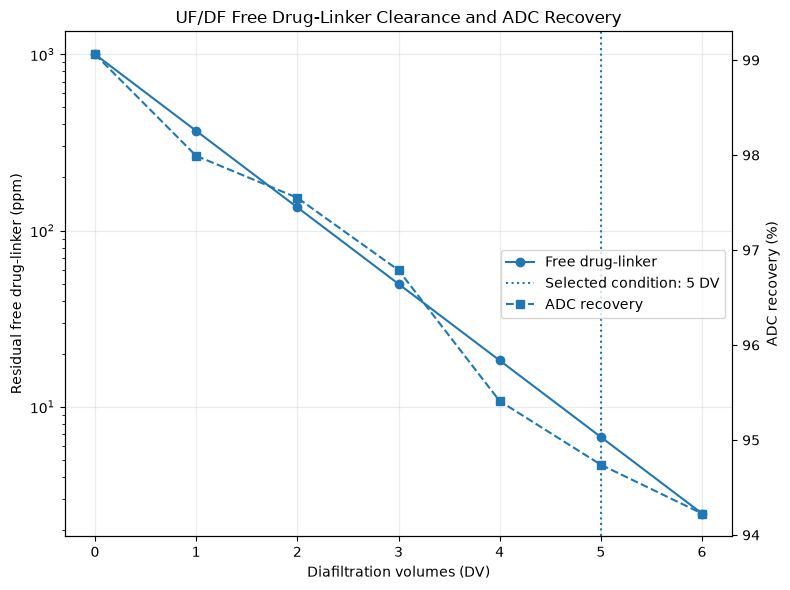

In [22]:
fig, ax1 = plt.subplots(figsize=(8, 6))

# Free drug-linker
ax1.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["free_drug_linker_ppm"],
    marker="o",
    label="Free drug-linker"
)

ax1.set_xlabel("Diafiltration volumes (DV)")
ax1.set_ylabel("Residual free drug-linker (ppm)")
ax1.set_yscale("log")

# ADC recovery on a second y-axis
ax2 = ax1.twinx()

ax2.plot(
    ufdf_results["diafiltration_volumes"],
    ufdf_results["adc_recovery_percent"],
    marker="s",
    linestyle="--",
    label="ADC recovery"
)

ax2.set_ylabel("ADC recovery (%)")

# Highlight selected condition
selected_dv = 5

ax1.axvline(
    selected_dv,
    linestyle=":",
    label="Selected condition: 5 DV"
)

ax1.set_title("UF/DF Free Drug-Linker Clearance and ADC Recovery")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center right"
)

ax1.grid(alpha=0.25)

plt.tight_layout()

ufdf_figure_file = FIGURES_DIR / "ufdf_clearance_recovery.png"

plt.savefig(
    ufdf_figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
ufdf_file = PROCESSED_DIR / "adc_ufdf_simulated_results.csv"

ufdf_results.to_csv(
    ufdf_file,
    index=False
)

ufdf_file

WindowsPath('C:/Users/trasn/OneDrive/Dokumente/programing/adc-downstream-process-development/data/processed/adc_ufdf_simulated_results.csv')

In [24]:
pd.read_csv(ufdf_file)

,diafiltration_volumes,free_drug_linker_ppm,adc_recovery_percent,linker_removal_percent
0,0,1000.000000,99.060943,0.000000
1,1,367.879441,97.992003,63.212056
2,2,135.335283,97.550090,86.466472
3,3,49.787068,96.788113,95.021293
4,4,18.315639,95.409793,98.168436
5,5,6.737947,94.739564,99.326205
6,6,2.478752,94.225568,99.752125


## Overall downstream process performance

The selected UF/DF operating condition is now combined with the preliminary
multimodal chromatography condition identified in the previous screening study.

Selected process:

**Post-conjugation material → 5 DV UF/DF → multimodal chromatography**

Selected MMC conditions:

- pH: 6.5
- NaCl: 300 mM
- load density: 10 mg ADC/mL resin

Because product losses occur sequentially, overall process recovery is
calculated by multiplying the fractional recovery of the individual unit
operations rather than averaging their recovery percentages.

In [25]:
ufdf_recovery = ufdf_results.loc[
    ufdf_results["diafiltration_volumes"] == 5,
    "adc_recovery_percent"
].iloc[0]

mmc_recovery = 92.45

overall_recovery = (
    (ufdf_recovery / 100)
    * (mmc_recovery / 100)
    * 100
)

print(f"UF/DF recovery: {ufdf_recovery:.2f}%")
print(f"MMC recovery: {mmc_recovery:.2f}%")
print(f"Overall downstream recovery: {overall_recovery:.2f}%")

UF/DF recovery: 94.74%
MMC recovery: 92.45%
Overall downstream recovery: 87.59%


### Overall recovery interpretation

The selected UF/DF condition provides 94.74% ADC recovery, while the selected
multimodal chromatography condition provides 92.45% recovery.

Because these unit operations occur sequentially, their recoveries are
multiplicative. The resulting overall downstream process recovery is 87.59%.

For example, starting with 100 mg of ADC-equivalent material would result in
approximately 94.74 mg remaining after UF/DF and approximately 87.59 mg after
the subsequent chromatography step.

This calculation illustrates why optimization of individual unit operations
must also consider their cumulative effect on overall process yield.

In [26]:
mmc_file = PROCESSED_DIR / "adc_mmc_simulated_results.csv"

mmc_results = pd.read_csv(mmc_file)

mmc_results.head()

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,free_drug_linker_ppm,mean_DAR
0,5.5,50,10,89.743774,3.331768,17.463263,4.061185
1,5.5,50,25,85.968013,3.717511,16.591812,4.054445
2,5.5,150,10,91.600361,2.772271,15.810623,4.018994
3,5.5,150,25,89.052452,3.222861,17.580711,4.089798
4,5.5,300,10,87.189172,2.383381,16.491905,3.920367


In [27]:
selected_mmc = mmc_results[
    (mmc_results["pH"] == 6.5)
    & (mmc_results["NaCl_mM"] == 300)
    & (mmc_results["load_mg_per_mL_resin"] == 10)
]

selected_mmc.round(2)

,pH,NaCl_mM,load_mg_per_mL_resin,recovery_percent,aggregate_percent,free_drug_linker_ppm,mean_DAR
10,6.5,300,10,92.45,1.91,16.65,3.95


In [28]:
ufdf_recovery = ufdf_results.loc[
    ufdf_results["diafiltration_volumes"] == 5,
    "adc_recovery_percent"
].iloc[0]

mmc_recovery = selected_mmc["recovery_percent"].iloc[0]

overall_recovery = (
    (ufdf_recovery / 100)
    * (mmc_recovery / 100)
    * 100
)

print(f"UF/DF recovery: {ufdf_recovery:.2f}%")
print(f"MMC recovery: {mmc_recovery:.2f}%")
print(f"Overall downstream recovery: {overall_recovery:.2f}%")

UF/DF recovery: 94.74%
MMC recovery: 92.45%
Overall downstream recovery: 87.59%


In [29]:
process_summary = pd.DataFrame({
    "Process step": [
        "UF/DF",
        "Multimodal chromatography",
        "Overall downstream process"
    ],
    "Selected condition": [
        "5 DV",
        "pH 6.5, 300 mM NaCl, 10 mg/mL resin",
        "UF/DF + MMC"
    ],
    "Recovery (%)": [
        ufdf_recovery,
        mmc_recovery,
        overall_recovery
    ]
})

process_summary["Recovery (%)"] = process_summary["Recovery (%)"].round(2)

process_summary

,Process step,Selected condition,Recovery (%)
0,UF/DF,5 DV,94.74
1,Multimodal chromatography,"pH 6.5, 300 mM NaCl, 10 mg/mL resin",92.45
2,Overall downstream process,UF/DF + MMC,87.59


## Conclusion

This simulated UF/DF development study evaluated the effect of increasing
diafiltration volumes on free drug-linker clearance and ADC recovery.

Free drug-linker concentration decreased rapidly with increasing diafiltration,
while ADC recovery declined more gradually. Based on the balance between
impurity clearance and product retention, 5 DV was selected as the preliminary
UF/DF operating condition. At this condition, simulated free drug-linker
removal reached 99.33% while ADC recovery remained at 94.74%.

The selected UF/DF condition was then combined with the preferred multimodal
chromatography condition identified in the preceding screening study:
pH 6.5, 300 mM NaCl, and a load density of 10 mg ADC/mL resin.

The chromatography step provided 92.45% recovery, resulting in an overall
simulated downstream process recovery of 87.59%.

Together, the two studies demonstrate how data analysis can support sequential
downstream process-development decisions by considering impurity clearance,
product quality, and cumulative process recovery.

All response data and process-selection thresholds used in this project are
simulated and should not be interpreted as experimental results or universal
ADC manufacturing specifications.